使用设备: cuda
------------------------------------------------------------------------------------------
成功读取数据: ../data/Training_set.csv, Shape: (277, 21)

====== 开始重新训练 (Fixed Copy Issue) ======
当前参数: {'hidden_dim': 39, 'num_experts': 5, 'learning_rate': 0.033052046662679385, 'batch_size': 64, 'num_epochs': 200}

开始训练 (Seed 24)...
Epoch [20/200] | Train Loss: 2.2327 | Val R2: 0.7808
Epoch [40/200] | Train Loss: 1.8818 | Val R2: 0.6885
Epoch [60/200] | Train Loss: 1.1760 | Val R2: 0.7419
Epoch [80/200] | Train Loss: 0.6273 | Val R2: 0.7420
Epoch [100/200] | Train Loss: 0.5530 | Val R2: 0.7445
Epoch [120/200] | Train Loss: 0.5892 | Val R2: 0.7427
Epoch [140/200] | Train Loss: 0.5462 | Val R2: 0.7428
Epoch [160/200] | Train Loss: 0.6060 | Val R2: 0.7427
Epoch [180/200] | Train Loss: 0.5427 | Val R2: 0.7427
Epoch [200/200] | Train Loss: 0.5415 | Val R2: 0.7427

训练结束，加载验证集表现最佳的模型...
最佳模型最终表现:
  Train R2 : 0.8486
  Val R2   : 0.7958 (Validation)


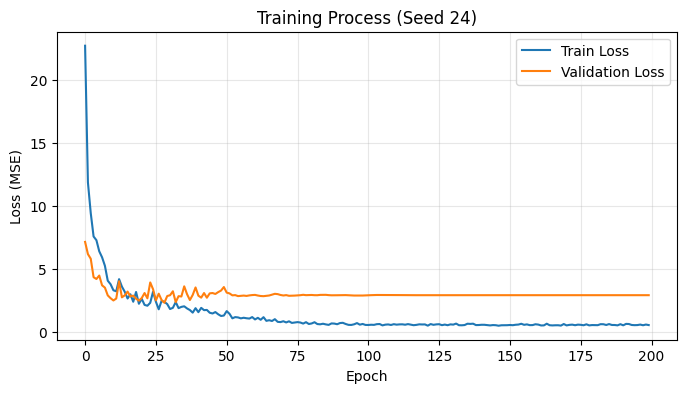

新模型已保存至: model.pth
标准化工具已保存至: scaler.pkl
预测数据已保存至: prediction_train.csv


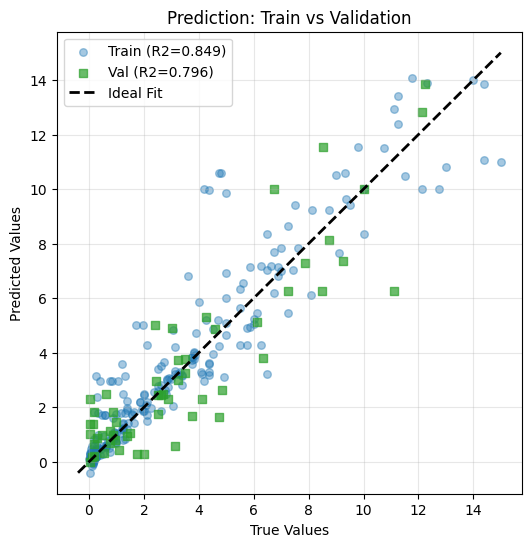


------ 最终验证：加载保存的模型 ------
保存的模型文件在验证集上的实际 R2: 0.7958
✅ 验证成功：保存的模型就是最佳模型！
=== 验证集一致性检查 ===
CSV 文件中读取计算的 R2: 0.795779
请对比训练结束时打印的 Best Val R2


In [3]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)


import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pandas as pd 
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from src.efficient_kan import KAN
import warnings
import random
import copy  # <--- 必须引入 copy 库
import joblib # <--- 用于保存 StandardScaler

warnings.filterwarnings('ignore')

# ----------------- 1. 基础设置 -----------------
def set_all_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device = get_device()
print(f"使用设备: {device}")

# ----------------- 2. 模型结构 -----------------
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Expert, self).__init__()
        self.fc1 = KAN([input_dim, hidden_dim, output_dim])
        
    def forward(self, x):
        x = self.fc1(x)
        return x

class MoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4):
        super(MoE, self).__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = nn.Linear(input_dim, num_experts)
        nn.init.normal_(self.gate.weight, mean=0.0, std=0.02)
        nn.init.constant_(self.gate.bias, 0.0)
        
    def forward(self, x, return_gate_weights=False):
        gate_scores = self.gate(x)
        gate_probs = F.softmax(gate_scores, dim=-1)
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        output = torch.einsum('be,beo->bo', gate_probs, expert_outputs)
        
        if return_gate_weights:
            return output, gate_probs
            
        return output

class SimpleMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts, output_dim=1):
        super(SimpleMoE, self).__init__()
        self.moe = MoE(input_dim, hidden_dim, output_dim, num_experts)
        
    def forward(self, x, return_gate_weights=False):
        if return_gate_weights:
            output, gate_probs = self.moe(x, return_gate_weights=True)
            return output.squeeze(-1), gate_probs
        else:
            output = self.moe(x)
            return output.squeeze(-1)

# ----------------- 3. 数据准备 (修改：返回 Scaler) -----------------
def load_and_process_data(seed):
    set_all_seeds(seed)
    train_path = r'../data/Training_set.csv'
    
    # --- A. 读取数据 ---
    try:
        df_full = pd.read_csv(train_path)
        if df_full.isnull().values.any(): df_full = df_full.dropna()
        print(f"成功读取数据: {train_path}, Shape: {df_full.shape}")
    except FileNotFoundError:
        print(f"警告: 找不到数据文件，使用虚拟数据演示...")
        rng = np.random.RandomState(seed)
        input_dim = 20 
        df_full = pd.DataFrame(rng.rand(100, input_dim+1))

    # --- B. 划分 ---
    train_data, val_data = train_test_split(
        df_full.values, test_size=0.2, random_state=seed
    )

    X_train_np = train_data[:, :-1]
    y_train_np = train_data[:, -1]
    X_val_np = val_data[:, :-1]
    y_val_np = val_data[:, -1]
    
    # --- C. 标准化 ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_np)
    X_val_scaled = scaler.transform(X_val_np)
    
    # --- D. 转 Tensor ---
    X_train = torch.FloatTensor(X_train_scaled).to(device)
    y_train = torch.FloatTensor(y_train_np).to(device)
    X_val = torch.FloatTensor(X_val_scaled).to(device)
    y_val = torch.FloatTensor(y_val_np).to(device)
    
    # 修改：返回 scaler 以便后续保存
    return X_train, y_train, X_val, y_val, scaler

# ----------------- 4. 训练函数 (修改：Deepcopy) -----------------
def train_model(params, X_train, y_train, X_val, y_val, seed, show_plots=True):
    set_all_seeds(seed)
    
    hidden_dim = int(params['hidden_dim'])
    num_experts = int(params['num_experts'])
    learning_rate = params['learning_rate']
    batch_size = int(params['batch_size'])
    num_epochs = int(params.get('num_epochs', 200)) 
    
    input_dim = X_train.shape[1]
    
    # 初始化模型
    model = SimpleMoE(input_dim, hidden_dim, num_experts).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    train_losses = []
    val_losses = [] 
    best_val_r2 = -float('inf') 
    best_model_state = None
    
    print(f"\n开始训练 (Seed {seed})...")
    
    for epoch in range(num_epochs):
        # --- A. 训练阶段 ---
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        
        epoch_loss = 0
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_y = X_train[indices], y_train[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / (X_train.size()[0] / batch_size)
        train_losses.append(avg_train_loss)
        
        # --- B. 验证阶段 ---
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val).item()
            val_losses.append(val_loss)
            
            y_pred_val = val_outputs.cpu().numpy()
            y_true_val = y_val.cpu().numpy()
            val_r2 = r2_score(y_true_val, y_pred_val)
            
            # 记录最佳模型 (核心修改：使用 deepcopy)
            if val_r2 > best_val_r2:
                best_val_r2 = val_r2
                # 【FIXED】使用 deepcopy，彻底断开与当前模型的内存连接
                best_model_state = copy.deepcopy(model.state_dict())
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val R2: {val_r2:.4f}')
    
    # --- C. 加载最佳模型 ---
    print("\n训练结束，加载验证集表现最佳的模型...")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    else:
        print("警告：未找到更优模型，保持最后状态")
    
    # 计算最终指标
    model.eval()
    with torch.no_grad():
        train_outputs = model(X_train)
        train_final_r2 = r2_score(y_train.cpu().numpy(), train_outputs.cpu().numpy())

    print(f"最佳模型最终表现:")
    print(f"  Train R2 : {train_final_r2:.4f}")
    print(f"  Val R2   : {best_val_r2:.4f} (Validation)")

    # 绘制 Loss 曲线
    if show_plots:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.title(f'Training Process (Seed {seed})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model, train_final_r2, best_val_r2

# ----------------- 主程序 -----------------
if __name__ == "__main__":
    
    # === 1. 固定种子与数据准备 ===
    # 接收 scaler


    print('------------------------------------------------------------------------------------------')
        
    seed=24
    X_train, y_train, X_val, y_val, scaler = load_and_process_data(seed)
    
    # === 2. 参数设置 ===
    manual_params = {
        'hidden_dim': 39,       
        'num_experts': 5,       
        'learning_rate':  0.033052046662679385, 
        'batch_size': 64,       
        'num_epochs': 200      
    }
    
    print("\n====== 开始重新训练 (Fixed Copy Issue) ======")
    print("当前参数:", manual_params)
    
    # === 3. 执行训练 ===
    best_model, train_r2, val_r2 = train_model(
        manual_params, X_train, y_train, X_val, y_val, seed=seed, show_plots=True
    )
    
    # === 4. 保存模型和 Scaler ===
    model_path = f'model.pth'
    scaler_path = f'scaler.pkl'
    
    # 保存权重
    torch.save(best_model.state_dict(), model_path)
    # 保存 Scaler (重要！用于新数据预测)
    joblib.dump(scaler, scaler_path)
    
    print(f"新模型已保存至: {model_path}")
    print(f"标准化工具已保存至: {scaler_path}")
    
    # === 5. 结果验证与可视化 ===
    best_model.eval()
    with torch.no_grad():
        # 获取训练集预测结果
        train_pred = best_model(X_train).cpu().numpy()
        train_real = y_train.cpu().numpy()
        # 获取验证集预测结果
        val_pred = best_model(X_val).cpu().numpy()
        val_real = y_val.cpu().numpy()

        df_train = pd.DataFrame({'True_Value': train_real, 'Predicted_Value': train_pred, 'Dataset': 'Training'})
        df_val = pd.DataFrame({'True_Value': val_real, 'Predicted_Value': val_pred, 'Dataset': 'Validation'})
        
        df_all = pd.concat([df_train, df_val], ignore_index=True)
        csv_path = f'prediction_train.csv'
        df_all.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"预测数据已保存至: {csv_path}")

    # 绘图
    plt.figure(figsize=(6, 6))
    plt.scatter(train_real, train_pred, alpha=0.4, label=f'Train (R2={train_r2:.3f})', color='#1f77b4', s=30)
    plt.scatter(val_real, val_pred, alpha=0.7, label=f'Val (R2={val_r2:.3f})', color='#2ca02c', marker='s', s=40)
    
    all_vals = np.concatenate([train_real, val_real, train_pred, val_pred])
    min_val, max_val = np.min(all_vals), np.max(all_vals)
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')
    
    plt.title('Prediction: Train vs Validation')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


    # === 6. 最终验证：加载保存的文件以确认 ===
    print("\n------ 最终验证：加载保存的模型 ------")
    loaded_model = SimpleMoE(X_train.shape[1], int(manual_params['hidden_dim']), int(manual_params['num_experts'])).to(device)
    loaded_model.load_state_dict(torch.load(model_path)) # <--- 统一使用 model_path 变量


    loaded_model.eval()
    with torch.no_grad():
        check_out = loaded_model(X_val)
        check_r2 = r2_score(y_val.cpu().numpy(), check_out.cpu().numpy())
    print(f"保存的模型文件在验证集上的实际 R2: {check_r2:.4f}")
    if abs(check_r2 - val_r2) < 1e-4:
        print("✅ 验证成功：保存的模型就是最佳模型！")
    else:
        print("❌ 验证失败：保存的模型与报告的不一致！")




    import pandas as pd
    from sklearn.metrics import r2_score

    # 1. 读取生成的 CSV
    csv_path = 'prediction_train.csv'  # 确保文件名对
    df = pd.read_csv(csv_path)

    # 2. 筛选出验证集 (Validation) 部分
    val_data = df[df['Dataset'] == 'Validation']

    y_true = val_data['True_Value'].values
    y_pred = val_data['Predicted_Value'].values

    # 3. 使用 sklearn 重新计算 R2
    calculated_r2 = r2_score(y_true, y_pred)

    print(f"=== 验证集一致性检查 ===")
    print(f"CSV 文件中读取计算的 R2: {calculated_r2:.6f}")
    print(f"请对比训练结束时打印的 Best Val R2")
        


使用设备: cuda
------------------------------------------------------------------------------------------
成功读取数据: d:\F\01.Moe_kan\data\Training_set.csv, Shape: (277, 21)

====== 开始重新训练 ======
当前参数: {'hidden_dim': 39, 'num_experts': 5, 'learning_rate': 0.033052046662679385, 'batch_size': 64, 'num_epochs': 200}

开始训练 (Seed 24)...
Epoch [20/200] | Train Loss: 2.5699 | Val R2: 0.7808
Epoch [40/200] | Train Loss: 2.1661 | Val R2: 0.6885
Epoch [60/200] | Train Loss: 1.3537 | Val R2: 0.7419
Epoch [80/200] | Train Loss: 0.7220 | Val R2: 0.7420
Epoch [100/200] | Train Loss: 0.6365 | Val R2: 0.7445
Epoch [120/200] | Train Loss: 0.6782 | Val R2: 0.7427
Epoch [140/200] | Train Loss: 0.6287 | Val R2: 0.7428
Epoch [160/200] | Train Loss: 0.6975 | Val R2: 0.7427
Epoch [180/200] | Train Loss: 0.6247 | Val R2: 0.7427
Epoch [200/200] | Train Loss: 0.6233 | Val R2: 0.7427

训练结束，加载验证集表现最佳的模型...
最佳模型最终表现:
  Train R2 : 0.8486
  Val R2   : 0.7958 (Validation)


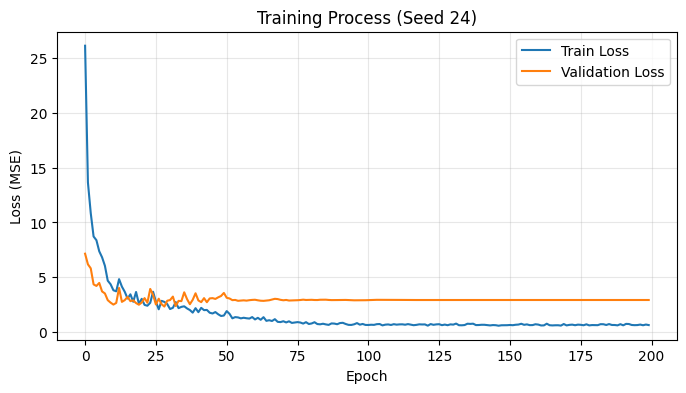


✅ 新模型已成功保存至: d:\F\01.Moe_kan\models\model.pth
✅ 标准化工具已成功保存至: d:\F\01.Moe_kan\models\scaler.pkl
📊 预测数据已保存至: d:\F\01.Moe_kan\data\prediction_train.csv


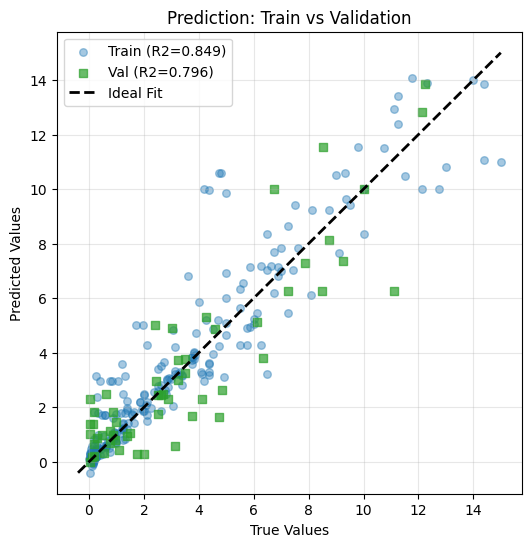


------ 最终验证：加载保存的模型 ------
保存的模型文件在验证集上的实际 R2: 0.7958
🎉 验证成功：保存的模型就是最佳模型！数据读取/保存路径全线打通！

=== 验证集一致性检查 ===
CSV 文件中读取计算的 R2: 0.795779
请对比训练结束时打印的 Best Val R2 (应完全一致)


In [6]:
import sys
import os

# ================= 路径配置 (核心修改点) =================
# 无论脚本在哪里运行，都能准确找到项目的根目录
# 如果是在 notebooks 目录下运行，getcwd() 是 notebooks，.. 就是根目录
# 如果直接在根目录下运行，可以通过检查当前目录是否包含 'data' 或 'src' 来更稳健地定位
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = os.path.abspath(current_dir)

if project_root not in sys.path:
    sys.path.append(project_root)

# 定义标准文件夹路径
DATA_DIR = os.path.join(project_root, 'data')
MODELS_DIR = os.path.join(project_root, 'models')

# 如果文件夹不存在，自动创建它们 (严格遵守 GitHub 结构)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
# =======================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd 
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from src.efficient_kan import KAN
import warnings
import random
import copy  
import joblib 

warnings.filterwarnings('ignore')

# ----------------- 1. 基础设置 -----------------
def set_all_seeds(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device = get_device()
print(f"使用设备: {device}")

# ----------------- 2. 模型结构 -----------------
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Expert, self).__init__()
        self.fc1 = KAN([input_dim, hidden_dim, output_dim])
        
    def forward(self, x):
        x = self.fc1(x)
        return x

class MoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4):
        super(MoE, self).__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = nn.Linear(input_dim, num_experts)
        nn.init.normal_(self.gate.weight, mean=0.0, std=0.02)
        nn.init.constant_(self.gate.bias, 0.0)
        
    def forward(self, x, return_gate_weights=False):
        gate_scores = self.gate(x)
        gate_probs = F.softmax(gate_scores, dim=-1)
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        output = torch.einsum('be,beo->bo', gate_probs, expert_outputs)
        
        if return_gate_weights:
            return output, gate_probs
            
        return output

class SimpleMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts, output_dim=1):
        super(SimpleMoE, self).__init__()
        self.moe = MoE(input_dim, hidden_dim, output_dim, num_experts)
        
    def forward(self, x, return_gate_weights=False):
        if return_gate_weights:
            output, gate_probs = self.moe(x, return_gate_weights=True)
            return output.squeeze(-1), gate_probs
        else:
            output = self.moe(x)
            return output.squeeze(-1)

# ----------------- 3. 数据准备 -----------------
def load_and_process_data(seed):
    set_all_seeds(seed)
    
    # 【修复路径】直接从 data 文件夹读取
    train_path = os.path.join(DATA_DIR, 'Training_set.csv')
    
    # --- A. 读取数据 ---
    try:
        df_full = pd.read_csv(train_path)
        if df_full.isnull().values.any(): df_full = df_full.dropna()
        print(f"成功读取数据: {train_path}, Shape: {df_full.shape}")
    except FileNotFoundError:
        print(f"❌ 警告: 找不到数据文件 {train_path}，使用虚拟数据演示...")
        rng = np.random.RandomState(seed)
        input_dim = 20 
        df_full = pd.DataFrame(rng.rand(100, input_dim+1))

    # --- B. 划分 ---
    train_data, val_data = train_test_split(
        df_full.values, test_size=0.2, random_state=seed
    )

    X_train_np = train_data[:, :-1]
    y_train_np = train_data[:, -1]
    X_val_np = val_data[:, :-1]
    y_val_np = val_data[:, -1]
    
    # --- C. 标准化 ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_np)
    X_val_scaled = scaler.transform(X_val_np)
    
    # --- D. 转 Tensor ---
    X_train = torch.FloatTensor(X_train_scaled).to(device)
    y_train = torch.FloatTensor(y_train_np).to(device)
    X_val = torch.FloatTensor(X_val_scaled).to(device)
    y_val = torch.FloatTensor(y_val_np).to(device)
    
    return X_train, y_train, X_val, y_val, scaler

# ----------------- 4. 训练函数 -----------------
def train_model(params, X_train, y_train, X_val, y_val, seed, show_plots=True):
    set_all_seeds(seed)
    
    hidden_dim = int(params['hidden_dim'])
    num_experts = int(params['num_experts'])
    learning_rate = params['learning_rate']
    batch_size = int(params['batch_size'])
    num_epochs = int(params.get('num_epochs', 200)) 
    
    input_dim = X_train.shape[1]
    
    # 初始化模型
    model = SimpleMoE(input_dim, hidden_dim, num_experts).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    train_losses = []
    val_losses = [] 
    best_val_r2 = -float('inf') 
    best_model_state = None
    
    print(f"\n开始训练 (Seed {seed})...")
    
    for epoch in range(num_epochs):
        # --- A. 训练阶段 ---
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        
        epoch_loss = 0
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_y = X_train[indices], y_train[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / (max(1, X_train.size()[0] // batch_size))
        train_losses.append(avg_train_loss)
        
        # --- B. 验证阶段 ---
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val).item()
            val_losses.append(val_loss)
            
            y_pred_val = val_outputs.cpu().numpy()
            y_true_val = y_val.cpu().numpy()
            val_r2 = r2_score(y_true_val, y_pred_val)
            
            # 记录最佳模型 (深拷贝断开内存引用)
            if val_r2 > best_val_r2:
                best_val_r2 = val_r2
                best_model_state = copy.deepcopy(model.state_dict())
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val R2: {val_r2:.4f}')
    
    # --- C. 加载最佳模型 ---
    print("\n训练结束，加载验证集表现最佳的模型...")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    else:
        print("警告：未找到更优模型，保持最后状态")
    
    # 计算最终指标
    model.eval()
    with torch.no_grad():
        train_outputs = model(X_train)
        train_final_r2 = r2_score(y_train.cpu().numpy(), train_outputs.cpu().numpy())

    print(f"最佳模型最终表现:")
    print(f"  Train R2 : {train_final_r2:.4f}")
    print(f"  Val R2   : {best_val_r2:.4f} (Validation)")

    # 绘制 Loss 曲线
    if show_plots:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.title(f'Training Process (Seed {seed})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model, train_final_r2, best_val_r2

# ----------------- 主程序 -----------------
if __name__ == "__main__":
    
    print('------------------------------------------------------------------------------------------')
        
    seed=24
    X_train, y_train, X_val, y_val, scaler = load_and_process_data(seed)
    
    # === 2. 参数设置 ===
    manual_params = {
        'hidden_dim': 39,       
        'num_experts': 5,       
        'learning_rate':  0.033052046662679385, 
        'batch_size': 64,       
        'num_epochs': 200      
    }
    
    print("\n====== 开始重新训练 ======")
    print("当前参数:", manual_params)
    
    # === 3. 执行训练 ===
    best_model, train_r2, val_r2 = train_model(
        manual_params, X_train, y_train, X_val, y_val, seed=seed, show_plots=True
    )
    
    # === 4. 保存模型和 Scaler (严格按结构存入 models 文件夹) ===
    # 【修复点】使用前文生成的全局变量 MODELS_DIR
    model_path = os.path.join(MODELS_DIR, 'model.pth')
    scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
    
    # 保存权重
    torch.save(best_model.state_dict(), model_path)
    # 保存 Scaler
    joblib.dump(scaler, scaler_path)
    
    print(f"\n✅ 新模型已成功保存至: {model_path}")
    print(f"✅ 标准化工具已成功保存至: {scaler_path}")
    
    # === 5. 结果验证与可视化 ===
    best_model.eval()
    with torch.no_grad():
        train_pred = best_model(X_train).cpu().numpy()
        train_real = y_train.cpu().numpy()
        val_pred = best_model(X_val).cpu().numpy()
        val_real = y_val.cpu().numpy()

        df_train = pd.DataFrame({'True_Value': train_real, 'Predicted_Value': train_pred, 'Dataset': 'Training'})
        df_val = pd.DataFrame({'True_Value': val_real, 'Predicted_Value': val_pred, 'Dataset': 'Validation'})
        
        df_all = pd.concat([df_train, df_val], ignore_index=True)
        
        # 【修复点】将预测结果保存到 data 文件夹，保持整洁
        csv_path = os.path.join(DATA_DIR, 'prediction_train.csv')
        df_all.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"📊 预测数据已保存至: {csv_path}")

    # 绘图
    plt.figure(figsize=(6, 6))
    plt.scatter(train_real, train_pred, alpha=0.4, label=f'Train (R2={train_r2:.3f})', color='#1f77b4', s=30)
    plt.scatter(val_real, val_pred, alpha=0.7, label=f'Val (R2={val_r2:.3f})', color='#2ca02c', marker='s', s=40)
    
    all_vals = np.concatenate([train_real, val_real, train_pred, val_pred])
    min_val, max_val = np.min(all_vals), np.max(all_vals)
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')
    
    plt.title('Prediction: Train vs Validation')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # === 6. 最终验证：加载保存的文件以确认 (解决之前报错的核心点) ===
    print("\n------ 最终验证：加载保存的模型 ------")
    loaded_model = SimpleMoE(X_train.shape[1], int(manual_params['hidden_dim']), int(manual_params['num_experts'])).to(device)
    
    # 【修复点】直接使用统一的变量 model_path
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()
    
    with torch.no_grad():
        check_out = loaded_model(X_val)
        check_r2 = r2_score(y_val.cpu().numpy(), check_out.cpu().numpy())
    
    print(f"保存的模型文件在验证集上的实际 R2: {check_r2:.4f}")
    if abs(check_r2 - val_r2) < 1e-4:
        print("🎉 验证成功：保存的模型就是最佳模型！数据读取/保存路径全线打通！")
    else:
        print("❌ 验证失败：保存的模型与报告的不一致！")

    # === 7. 验证保存的 CSV 一致性 ===
    # 【修复点】读取刚才保存的正确的 csv_path
    df_read = pd.read_csv(csv_path)
    val_data = df_read[df_read['Dataset'] == 'Validation']
    calculated_r2 = r2_score(val_data['True_Value'], val_data['Predicted_Value'])

    print(f"\n=== 验证集一致性检查 ===")
    print(f"CSV 文件中读取计算的 R2: {calculated_r2:.6f}")
    print(f"请对比训练结束时打印的 Best Val R2 (应完全一致)")